# 07 - Clustering & Spatial Domains

## Learning objectives
1. Build a neighbor graph, run UMAP, and cluster spots with Leiden.
2. Visualize clusters in UMAP space and over the histology.
3. Distinguish **transcriptomic clusters** from **morphological regions**.
4. Find per-cluster marker genes and export a table.

## Concept
Clustering groups spots with similar expression - **unsupervised segmentation in feature
space**. UMAP is a 2D map for visualization (like t-SNE). Leiden finds communities in the
nearest-neighbor graph. Mapping clusters back onto tissue reveals spatial domains.


In [1]:
# --- Standard setup: make `utils` importable and seed RNGs ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'utils').exists():
    ROOT = ROOT.parent  # in case the notebook is opened from a subfolder
sys.path.insert(0, str(ROOT))

from utils import st_helpers as st
st.set_seeds()  # reproducibility (seed = 0)
print('Project root:', st.project_root())


Project root: /Users/justin/Documents/SpatialTranscriptomics-Tutorial


In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd

adata = st.load_adata('adata_qc.h5ad')
assert 'X_pca' in adata.obsm, 'Run notebook 04 first (PCA is computed there).'
adata


AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### Neighbor graph + UMAP + Leiden
We use the PCA from notebook 04 (first ~30 PCs), build a kNN graph, embed with UMAP, and
cluster with Leiden. All seeded for reproducibility.

In [3]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=st.SEED)
sc.tl.umap(adata, random_state=st.SEED)
st.run_leiden(adata, resolution=1.0, key_added='clusters', seed=st.SEED)
print('Number of Leiden clusters:', adata.obs['clusters'].nunique())
adata.obs['clusters'].value_counts().sort_index()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Number of Leiden clusters: 17


clusters
0     326
1     232
2     238
3     213
4     250
5     263
6     155
7      66
8     205
9     121
10    103
11     38
12     85
13     58
14    204
15     70
16     61
Name: count, dtype: int64

### Clusters in UMAP space

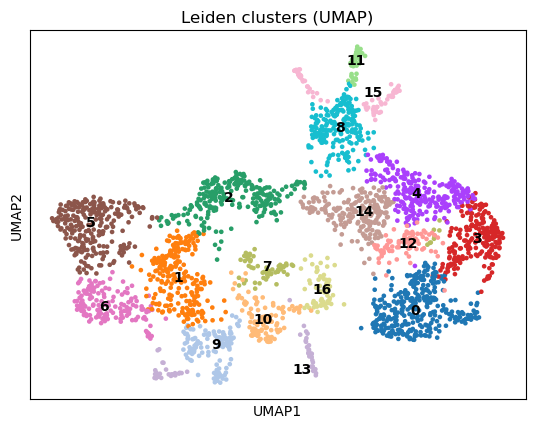

In [4]:
sc.pl.umap(adata, color='clusters', legend_loc='on data', title='Leiden clusters (UMAP)')


### Clusters over the histology (spatial domains)

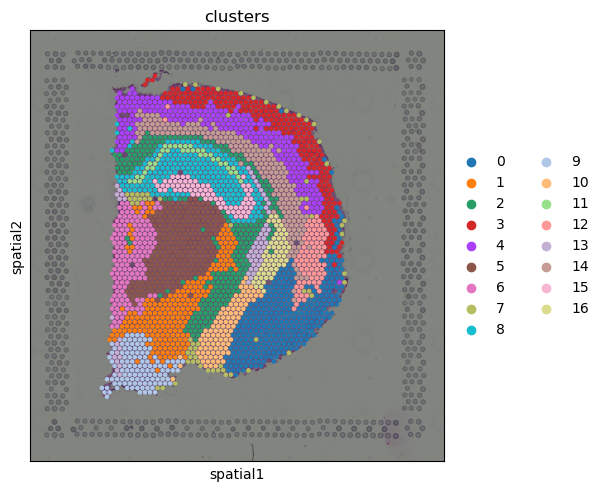

In [5]:
sq.pl.spatial_scatter(adata, color='clusters', size=1.4)


**Expected output:** ~10-20 clusters that, on the tissue, form **spatially coherent
domains** mirroring brain anatomy (cortical layers, white matter, hippocampus, etc.) -
even though clustering used only expression, not position.

### Transcriptomic clusters vs morphological regions
These clusters come purely from expression. They often align with morphology you can see
in the H&E, but **not always**: two regions can look alike on H&E yet differ molecularly
(and vice versa). That mismatch is scientifically interesting - and the motivation for
notebook 10, where we ask how well morphology predicts the transcriptomic cluster.

### Spatial graph (optional, for spatial methods)
Squidpy can build a graph on the **hex grid** (spatial neighbors), used by spatially aware
methods like Moran's I in notebook 08.

In [6]:
sq.gr.spatial_neighbors(adata, coord_type='grid', n_neighs=6)
print('spatial graph stored in adata.obsp:', [k for k in adata.obsp.keys()])


INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


spatial graph stored in adata.obsp: ['connectivities', 'distances', 'spatial_connectivities', 'spatial_distances']


### Marker genes per cluster
`rank_genes_groups` runs a one-vs-rest test per cluster (Wilcoxon) to find genes that
define it - the molecular 'label' for each segment. We export the top markers to CSV.

In [7]:
sc.tl.rank_genes_groups(adata, 'clusters', method='wilcoxon')
markers = sc.get.rank_genes_groups_df(adata, group=None)
top_markers = (markers.sort_values(['group', 'scores'], ascending=[True, False])
                      .groupby('group').head(10).reset_index(drop=True))
markers_csv = st.outputs_dir() / 'cluster_markers.csv'
st.save_root_result_table(
    top_markers, markers_csv, result_name='cluster_markers',
    upstream_lineage={'adata_qc': st.root_artifact_lineage('adata_qc.h5ad')},
)
print('Wrote', markers_csv)
top_markers.head(20)


Wrote /Users/justin/Documents/SpatialTranscriptomics-Tutorial/outputs/cluster_markers.csv


/var/folders/dc/d6wdtqms1zl0fcy03491kj6m0000gn/T/ipykernel_13019/573389498.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('group').head(10).reset_index(drop=True))


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Nptxr,25.735954,1.249912,4.630149e-146,8.370384e-142
1,0,Slc30a3,21.159954,2.023115,2.234412e-99,2.019685e-95
2,0,Syn2,20.870285,0.674546,9.973647e-97,6.010120e-93
3,0,Olfm1,20.834352,0.495055,2.113519e-96,9.552049e-93
4,0,Lmo3,20.335712,1.651062,6.213112e-92,2.246413e-88
5,0,Lypd1,19.529741,1.675798,6.134961e-85,1.848464e-81
6,0,Hpcal4,19.482161,0.892793,1.555727e-84,4.017775e-81
7,0,Nov,18.934151,1.763769,5.966994e-80,1.348391e-76
8,0,Hpcal1,18.843407,1.491687,3.328421e-79,6.685689e-76
9,0,Ddn,18.514074,1.086294,1.590055e-76,2.874501e-73


/var/folders/dc/d6wdtqms1zl0fcy03491kj6m0000gn/T/ipykernel_13019/2910861222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top3 = (top_markers.groupby('group').head(3)['names'].tolist())


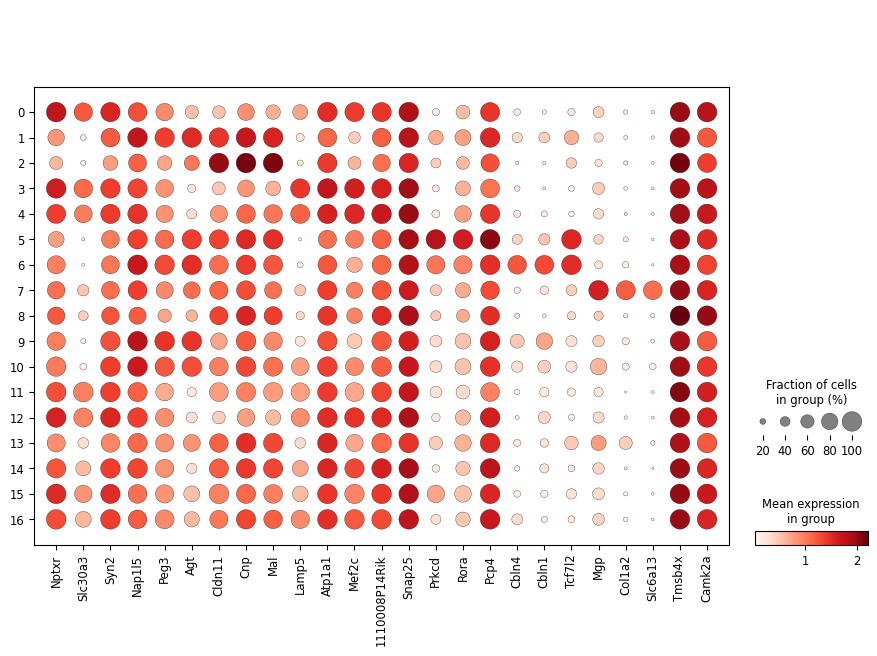

In [8]:
# Quick look: top-3 markers per cluster on a dotplot.
top3 = (top_markers.groupby('group').head(3)['names'].tolist())
top3 = st.genes_present(adata, dict.fromkeys(top3))  # dedupe + existence check
sc.pl.dotplot(adata, var_names=top3[:25], groupby='clusters')


### Top marker genes per cluster — spatial panels
For the three largest clusters we plot the #1 ranked marker spatially. This links each
transcriptomic domain to a concrete molecular signature on the tissue.

Top markers for largest clusters: ['Nptxr', 'Prkcd', '1110008P14Rik']


/var/folders/dc/d6wdtqms1zl0fcy03491kj6m0000gn/T/ipykernel_13019/2887002047.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('group').head(1))


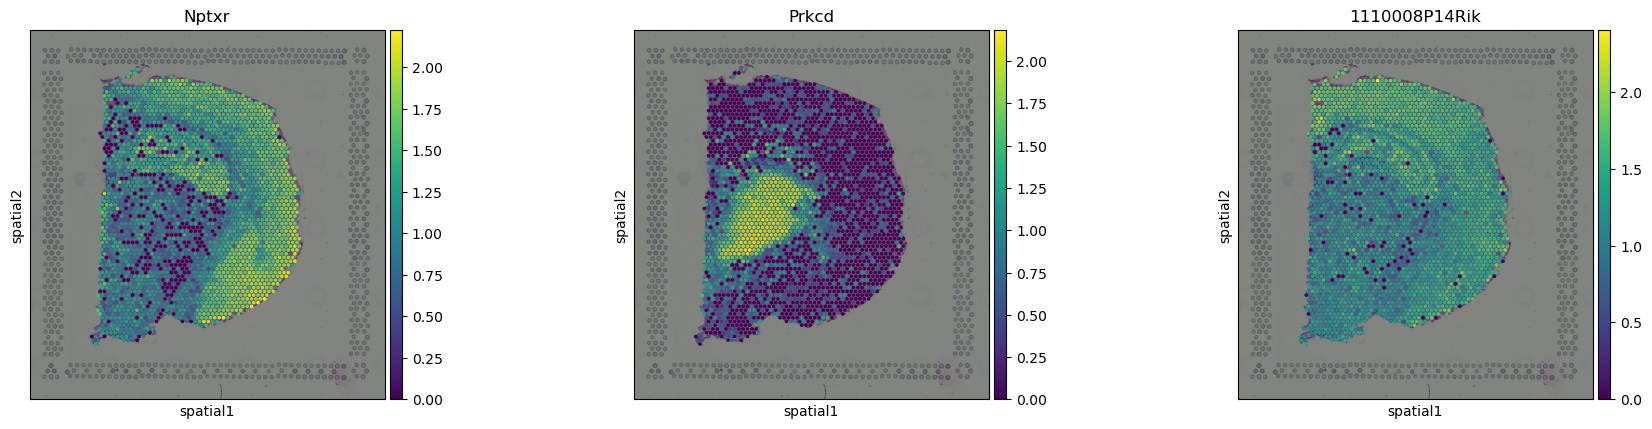

In [9]:
import matplotlib.pyplot as plt

top1 = (top_markers.sort_values(['group', 'scores'], ascending=[True, False])
                   .groupby('group').head(1))
top_clusters = adata.obs['clusters'].value_counts().head(3).index.astype(str).tolist()
spatial_genes = []
for cl in top_clusters:
    row = top1[top1['group'].astype(str) == cl]
    if len(row):
        g = row.iloc[0]['names']
        if g in adata.var_names:
            spatial_genes.append(g)
spatial_genes = list(dict.fromkeys(spatial_genes))  # dedupe
print('Top markers for largest clusters:', spatial_genes)
if spatial_genes:
    sq.pl.spatial_scatter(adata, color=spatial_genes, ncols=3, size=1.3)
    fig = plt.gcf()
    st.save_fig(fig, '07_top_cluster_markers_spatial.png')


<details>
<summary><b>Your turn (exercise)</b></summary>

**Prompt:** Cluster 0's top marker gene — does its spatial pattern match the cluster's
spatial domain on the tissue?

**Expected answer:** Yes, for a well-separated cluster the top marker should be enriched
exactly where that cluster sits on the histology overlay. Mismatches suggest mixed spots,
over-clustering, or a marker that is high in multiple regions.
</details>


In [10]:
saved = st.save_adata(adata, 'adata_clustered.h5ad')
print('Wrote', saved)


Wrote /Users/justin/Documents/SpatialTranscriptomics-Tutorial/data/processed/adata_clustered.h5ad


## Common pitfalls
- No `leidenalg`/`igraph` installed -> Leiden fails (the helper falls back; install both).
- Changing `resolution` changes cluster count - there is no single 'true' number.
- Reading cluster numbers as cell types - they are spot groups; annotate via markers (nb 11).

## Interpretation
Unsupervised clustering recovered tissue domains from expression alone, and each domain has
a marker-gene signature you can export and inspect.

## What this means biologically
The brain is spatially organized into regions with distinct molecular programs. That the
clusters reproduce known anatomy validates the pipeline and lets us name domains by their
marker genes.

---
**Next:** `08_spatially_variable_genes.ipynb`.
